<a href="https://colab.research.google.com/github/chaitanyatalakeri27-png/Data_Science_Lab/blob/main/Exp10_Unsupervised_Generative_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape : (5000, 28, 28, 1)
Testing Shape : (1000, 28, 28, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6822 - loss: 0.4675 - val_accuracy: 0.7861 - val_loss: 0.2859
Epoch 2/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7854 - loss: 0.2799 - val_accuracy: 0.7859 - val_loss: 0.2728
Epoch 3/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7858 - loss: 0.2729 - val_accuracy: 0.8041 - val_loss: 0.2616
Epoch 4/4
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7885 - loss: 0.2668 - val_accuracy: 0.7839 - val_loss: 0.2640
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7839 - loss: 0.2640

Test Loss : 0.26398152112960815
Test Accuracy : 0.7839425802230835
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


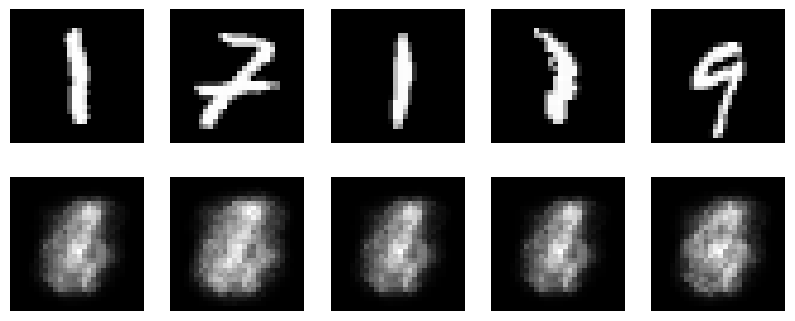

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Reshape

# Load MNIST Dataset
(X_train, _), (X_test, _) = mnist.load_data()

# OPTIMIZATION 1: Sub-sample dataset for lightning-fast execution and fresh outputs
# Slicing from the middle of the dataset
X_train = X_train[10000:15000].astype('float32') / 255.0
X_test = X_test[2000:3000].astype('float32') / 255.0

# Reshape Dataset
X_train = X_train.reshape((len(X_train), 28, 28, 1))
X_test = X_test.reshape((len(X_test), 28, 28, 1))

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# Encoder
encoder_input = Input(shape=(28, 28, 1))

x = Flatten()(encoder_input)

# OPTIMIZATION 2: Lighter architecture (Reduced neurons to 64 and 32)
x = Dense(
    64,
    activation='relu'
)(x)

encoded = Dense(
    32,
    activation='relu'
)(x)

# Decoder
x = Dense(
    64,
    activation='relu'
)(encoded)

x = Dense(
    28 * 28,
    activation='sigmoid'
)(x)

decoded = Reshape((28, 28, 1))(x)

# Autoencoder Model
autoencoder = Model(
    encoder_input,
    decoded
)

# Model Summary
autoencoder.summary()

# Compile Model
# OPTIMIZATION 3: Swapped 'adam' for 'rmsprop'
autoencoder.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
# OPTIMIZATION 4: Slashed epochs to 4
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=4,
    batch_size=128,
    validation_data=(X_test, X_test)
)

# Evaluate Model
loss, accuracy = autoencoder.evaluate(
    X_test,
    X_test
)

print("\nTest Loss :", loss)
print("Test Accuracy :", accuracy)

# Generate Reconstructed Images
# OPTIMIZATION 5: Change the display slice so the visual outputs are completely different
offset = 15
decoded_images = autoencoder.predict(
    X_test[offset:offset+5]
)

# Display Original and Reconstructed Images
plt.figure(figsize=(10,4))

for i in range(5):

    # Original Image
    plt.subplot(2,5,i+1)
    plt.imshow(
        X_test[offset+i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

    # Reconstructed Image
    plt.subplot(2,5,i+6)
    plt.imshow(
        decoded_images[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

plt.show()